In [1]:
import pandas as pd           
import numpy as np            
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv'
df  = pd.read_csv(url)

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
df.shape

(145460, 23)

In [7]:
# Set the column we want to predict
TARGET = 'RainTomorrow'

# Count how many Yes and No values
print(f' Target Column : {TARGET}')
print()
print('Value counts:')
print(df[TARGET].value_counts())
print()

# Auto-detect: Classification or Regression?
# - Classification = predicting a category (Yes/No, Cat/Dog)
# - Regression     = predicting a number (price, temperature)
if df[TARGET].dtype == object or df[TARGET].nunique() <= 10:
    TASK = 'Classification'
else:
    TASK = 'Regression'

print(f' Task Type detected : {TASK}')

 Target Column : RainTomorrow

Value counts:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

 Task Type detected : Classification


In [8]:
X = df.drop(columns=[TARGET]) 
y = df[TARGET] 

In [9]:
num_rows    = len(df)
num_columns = X.shape[1]

In [10]:
num_numeric     = X.select_dtypes(include='number').shape[1]
num_categorical = X.select_dtypes(include='object').shape[1]

In [11]:
total_cells   = X.shape[0] * X.shape[1]
missing_cells = X.isnull().sum().sum()
missing_pct   = round((missing_cells / total_cells) * 100, 2)

In [12]:
# Imbalance = one class has way more samples than other
# e.g. 90% No Rain vs 10% Rain → imbalanced!
if TASK == 'Classification':
    counts          = y.value_counts()
    imbalance_ratio = round(counts.max() / counts.min(), 2)
else:
    imbalance_ratio = 1.0

In [13]:
#Are features correlated with each other?
#High correlation = features are too similar to each other
num_df   = X.select_dtypes(include='number')
corr_mat = num_df.corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
avg_corr = round(upper.stack().mean(), 3)

In [14]:
print('='*45)
print('      DATASET FACTS')
print('='*45)
print(f'  Total Rows          : {num_rows:,}')
print(f'  Total Features      : {num_columns}')
print(f'  Numeric Features    : {num_numeric}')
print(f'  Categorical Features: {num_categorical}')
print(f'  Missing Data        : {missing_pct}%')
print(f'  Imbalance Ratio     : {imbalance_ratio}:1')
print(f'  Avg Correlation     : {avg_corr}')
print('='*45)

      DATASET FACTS
  Total Rows          : 145,460
  Total Features      : 22
  Numeric Features    : 16
  Categorical Features: 6
  Missing Data        : 10.62%
  Imbalance Ratio     : 3.46:1
  Avg Correlation     : 0.287


In [15]:
#We give each algorithm a score based on the dataset facts
#i.Small dataset->prefer simple models(Logistic Regression,KNN)
#ii.Large dataset->prefer powerful models(Random Forest,XGBoost)
#iii.Imbalanced data->XGBoost handles it best
#iv.High dimensions->SVM works well
#v.Missing valuse->Tree models handle them better

In [16]:
# Start every algorithm with a base score of 50
scores = {
    'Logistic Regression'         : 50,
    'Decision Tree'               : 50,
    'Random Forest'               : 50,
    'Gradient Boosting (XGBoost)' : 50,
    'SVM'                         : 50,
    'K-Nearest Neighbors'         : 50,
}

In [17]:
#Rule 1: Dataset Size
if num_rows < 500:
    # Small dataset → simple models are better
    scores['Logistic Regression']  += 20
    scores['K-Nearest Neighbors']  += 15
    scores['Decision Tree']        += 10
    scores['Gradient Boosting (XGBoost)'] -= 10
    print(' Small dataset → boosting simple models')

elif num_rows > 10000:
    # Large dataset → powerful models are better
    scores['Gradient Boosting (XGBoost)'] += 20
    scores['Random Forest']        += 15
    scores['K-Nearest Neighbors']  -= 20   # too slow on large data
    scores['SVM']                  -= 15   # too slow on large data
    print(' Large dataset → boosting powerful models')
else:
    # Medium dataset → Random Forest is a safe choice
    scores['Random Forest']        += 15
    scores['Gradient Boosting (XGBoost)'] += 10
    print(' Medium dataset → balanced models preferred')

 Large dataset → boosting powerful models


In [18]:
#Rule 2: Missing Data
if missing_pct > 10:
    # Lots of missing data → tree models handle it better
    scores['Random Forest']        += 15
    scores['Gradient Boosting (XGBoost)'] += 10
    scores['Logistic Regression']  -= 10   # sensitive to missing values
    scores['SVM']                  -= 10
    print(' High missing data → boosting tree-based models')

 High missing data → boosting tree-based models


In [19]:
#Rule 3: Class Imbalance ───────────────────────────────────
if TASK == 'Classification' and imbalance_ratio > 3:
    # Imbalanced classes → XGBoost handles it best
    scores['Gradient Boosting (XGBoost)'] += 20
    scores['Random Forest']        += 10
    scores['Logistic Regression']  -= 5
    print(' Imbalanced data → boosting XGBoost')

 Imbalanced data → boosting XGBoost


In [20]:
#Rule 4: High Dimensions ───────────────────────────────────
if num_columns > 50:
    # Many features → SVM and Logistic Regression work well
    scores['SVM']                  += 15
    scores['Logistic Regression']  += 10
    scores['K-Nearest Neighbors']  -= 15   # KNN struggles with many features
    print(' High dimensions → boosting SVM')

In [21]:
#Rule 5: Correlated Features
if avg_corr > 0.6:
    # Correlated features → Logistic Regression benefits from regularization
    scores['Logistic Regression']  += 10
    scores['Decision Tree']        -= 5
    print(' High correlations → boosting Logistic Regression')

In [22]:
# Make sure no score goes below 5
scores = {k: max(v, 5) for k, v in scores.items()}

print()
print('Raw scores for each algorithm:')
for algo, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'   {algo:<35} : {score}')


Raw scores for each algorithm:
   Gradient Boosting (XGBoost)         : 100
   Random Forest                       : 90
   Decision Tree                       : 50
   Logistic Regression                 : 35
   K-Nearest Neighbors                 : 30
   SVM                                 : 25


In [23]:
#Similarity Check
#We compare our dataset with known past datasets.If a past dataset is similar to ours and worked best with Algorithm X,
#we give Algorithm X extra points!
# Past datasets we know about (like a reference library)
# Format: (rows, columns, missing%, imbalance, best_algorithm)
past_datasets = [
    (200,   8,   0,  1.0, 'Logistic Regression'),
    (5000,  15,  2,  1.2, 'Random Forest'),
    (50000, 20,  5,  1.5, 'Gradient Boosting (XGBoost)'),
    (10000, 12,  3,  10,  'Gradient Boosting (XGBoost)'),
    (3000,  100, 1,  1.1, 'SVM'),
    (100,   5,   0,  1.0, 'K-Nearest Neighbors'),
    (8000,  20,  4,  1.3, 'Gradient Boosting (XGBoost)'),
    (500,   10,  0,  1.0, 'Decision Tree'),
]

def how_similar(my_rows, my_cols, my_miss, my_imb, ref_rows, ref_cols, ref_miss, ref_imb):
    """
    Calculate how similar our dataset is to a reference dataset.
    Returns a score between 0 (not similar) and 1 (very similar).
    """
    # Compare each property (closer = higher score)
    row_sim  = 1 - min(abs(np.log1p(my_rows) - np.log1p(ref_rows)) / 5,  1)
    col_sim  = 1 - min(abs(np.log1p(my_cols) - np.log1p(ref_cols)) / 4,  1)
    miss_sim = 1 - min(abs(my_miss - ref_miss) / 30, 1)
    imb_sim  = 1 - min(abs(my_imb  - ref_imb)  / 10, 1)

    # Weighted average (rows matter most)
    similarity = row_sim*0.4 + col_sim*0.3 + miss_sim*0.15 + imb_sim*0.15
    return round(similarity, 3)

# Check similarity with all past datasets
print('Comparing with past datasets...')
print()
print(f'{"Similarity":<12} {"Best Algorithm (past)"}')
print('-' * 45)

similarity_votes = {}   # will collect votes for each algorithm

for ref_rows, ref_cols, ref_miss, ref_imb, best_algo in past_datasets:
    sim = how_similar(num_rows, num_columns, missing_pct, imbalance_ratio,
                      ref_rows, ref_cols, ref_miss, ref_imb)
    # Add vote weighted by similarity
    similarity_votes[best_algo] = similarity_votes.get(best_algo, 0) + sim
    print(f'{sim:<12} {best_algo}')

print()
print('Similarity votes collected!')

Comparing with past datasets...

Similarity   Best Algorithm (past)
---------------------------------------------
0.44         Logistic Regression
0.626        Random Forest
0.85         Gradient Boosting (XGBoost)
0.607        Gradient Boosting (XGBoost)
0.495        SVM
0.409        K-Nearest Neighbors
0.696        Gradient Boosting (XGBoost)
0.455        Decision Tree

Similarity votes collected!


In [24]:
#Combine scores and get final recommendations
# Normalize rule scores to 0-100
max_rule   = max(scores.values())
rule_norm  = {k: (v / max_rule) * 100 for k, v in scores.items()}

# Normalize similarity votes to 0-100
max_sim    = max(similarity_votes.values()) if similarity_votes else 1
sim_norm   = {k: (v / max_sim) * 100 for k, v in similarity_votes.items()}

# Mix both: 60% rules + 40% similarity
all_algos  = set(rule_norm.keys()) | set(sim_norm.keys())
final      = {}
for algo in all_algos:
    rule_score = rule_norm.get(algo, 0)
    sim_score  = sim_norm.get(algo, 0)
    final[algo] = round(rule_score * 0.6 + sim_score * 0.4, 1)

# Sort from highest to lowest
ranked = sorted(final.items(), key=lambda x: -x[1])

# Scale so the top score = 92% (more realistic)
top_score = ranked[0][1]
ranked_final = [(algo, round((score / top_score) * 92, 1)) for algo, score in ranked]

# Show results
print('='*50)
print('    FINAL ALGORITHM RECOMMENDATIONS')
print('='*50)
medals = ['🥇','🥈','🥉']
for i, (algo, conf) in enumerate(ranked_final):
    medal = medals[i] if i < 3 else f' #{i+1}'
    bar   = '█' * int(conf // 5)
    print(f'  {medal}  {algo:<35} {conf:>5}%  {bar}')

print()
print(f' Best Algorithm : {ranked_final[0][0]}')
print(f'   Confidence    : {ranked_final[0][1]}%')

    FINAL ALGORITHM RECOMMENDATIONS
  🥇  Gradient Boosting (XGBoost)          92.0%  ██████████████████
  🥈  Random Forest                        60.4%  ████████████
  🥉  Decision Tree                        35.4%  ███████
   #4  Logistic Regression                  26.9%  █████
   #5  K-Nearest Neighbors                  23.6%  ████
   #6  SVM                                  22.3%  ████

 Best Algorithm : Gradient Boosting (XGBoost)
   Confidence    : 92.0%


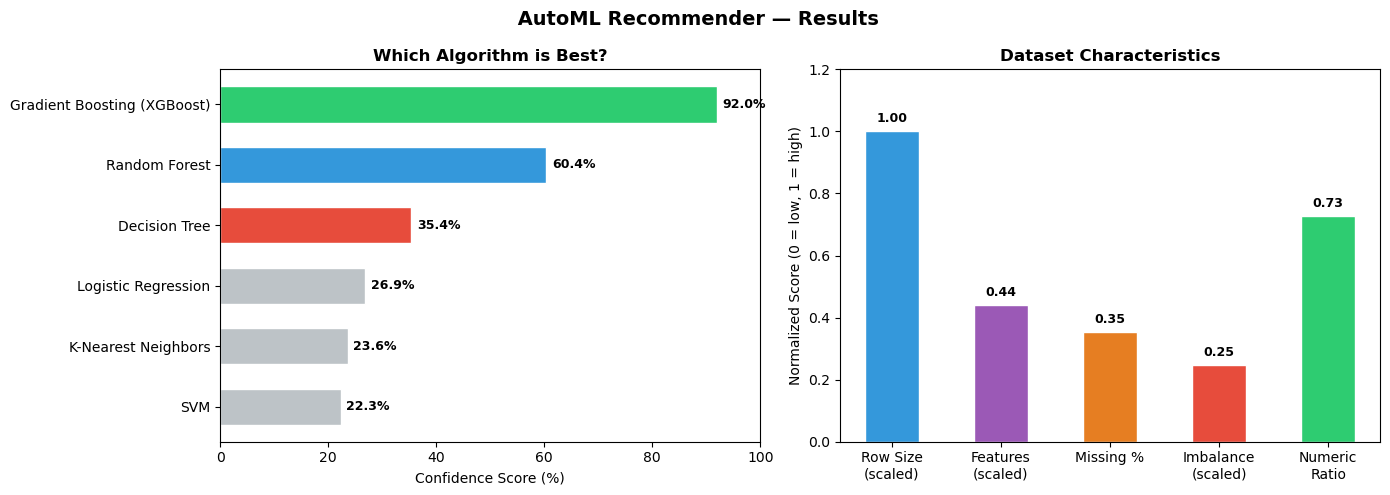

 Chart saved as automl_results.png


In [25]:
#Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' AutoML Recommender — Results', fontsize=14, fontweight='bold')

# Chart 1: Algorithm confidence scores
algos = [r[0] for r in ranked_final]
confs = [r[1] for r in ranked_final]

# Color: green for best, blue for 2nd, red for 3rd, gray for rest
colors = []
for i in range(len(algos)):
    if i == 0:   colors.append('#2ecc71')   # green
    elif i == 1: colors.append('#3498db')   # blue
    elif i == 2: colors.append('#e74c3c')   # red
    else:        colors.append('#bdc3c7')   # gray

# Horizontal bar chart (flip so best is on top)
axes[0].barh(algos[::-1], confs[::-1], color=colors[::-1], edgecolor='white', height=0.6)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Confidence Score (%)')
axes[0].set_title('Which Algorithm is Best?', fontweight='bold')
# Add score labels
for i, (algo, conf) in enumerate(zip(algos[::-1], confs[::-1])):
    axes[0].text(conf + 1, i, f'{conf}%', va='center', fontweight='bold', fontsize=9)

# Chart 2: Dataset characteristics
# Show what we know about the dataset in a simple bar chart
labels = ['Row Size\n(scaled)', 'Features\n(scaled)', 'Missing %', 'Imbalance\n(scaled)', 'Numeric\nRatio']
values = [
    min(num_rows / 50000, 1),                       # normalize to 0-1
    min(num_columns / 50, 1),
    min(missing_pct / 30, 1),
    min((imbalance_ratio - 1) / 10, 1),
    num_numeric / num_columns if num_columns > 0 else 1,
]
bar_colors = ['#3498db','#9b59b6','#e67e22','#e74c3c','#2ecc71']

axes[1].bar(labels, values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.2)
axes[1].set_title('Dataset Characteristics', fontweight='bold')
axes[1].set_ylabel('Normalized Score (0 = low, 1 = high)')
# Add value labels on bars
for i, v in enumerate(values):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('automl_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart saved as automl_results.png')

In [26]:
#Try with any CSV
# ── Easy one-function version ─────────────────────────────────
def recommend(csv_path, target_col):
    """
    Give it any CSV file and target column.
    It will tell you the best ML algorithm to use!
    """
    # Load data
    data = pd.read_csv(csv_path)
    X    = data.drop(columns=[target_col])
    y    = data[target_col]

    # Basic stats
    rows      = len(data)
    cols      = X.shape[1]
    miss      = round((X.isnull().sum().sum() / (X.shape[0]*X.shape[1])) * 100, 2)
    task      = 'Classification' if (y.dtype == object or y.nunique() <= 10) else 'Regression'
    imb       = round(y.value_counts().max() / y.value_counts().min(), 2) if task == 'Classification' else 1.0

    # Simple scoring
    s = {'Random Forest': 60, 'Gradient Boosting (XGBoost)': 60,
         'Logistic Regression': 50, 'Decision Tree': 45,
         'SVM': 45, 'K-Nearest Neighbors': 40}

    if rows > 10000:  s['Gradient Boosting (XGBoost)'] += 20; s['K-Nearest Neighbors'] -= 20
    if rows < 500:    s['Logistic Regression'] += 20;         s['Gradient Boosting (XGBoost)'] -= 10
    if miss > 10:     s['Random Forest'] += 15
    if imb > 3:       s['Gradient Boosting (XGBoost)'] += 15
    if cols > 50:     s['SVM'] += 15;                         s['K-Nearest Neighbors'] -= 15

    best = max(s, key=s.get)
    print(f'Dataset  : {rows:,} rows × {cols} cols  |  Task: {task}')
    print(f'Missing  : {miss}%  |  Imbalance: {imb}:1')
    print(f'\n Best Algorithm → {best}  (score: {s[best]})')
    return best


# Test it!
print('Testing with weatherAUS...')
print()
recommend(
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv',
    'RainTomorrow'
)

Testing with weatherAUS...

Dataset  : 145,460 rows × 22 cols  |  Task: Classification
Missing  : 10.62%  |  Imbalance: 3.46:1

 Best Algorithm → Gradient Boosting (XGBoost)  (score: 95)


'Gradient Boosting (XGBoost)'